# Figure 4 -- Effect of Supervision

Reproduces **Figure 4** of the arxiv_v2 manuscript
(`paper/sections_arxiv_v2/3_experiments_2.tex`, `fig:supervision`): 8 panels
(A-H) showing how supervision affects source recovery on the "neural-like"
1/f background + theta(6Hz)/gamma(40Hz) burst simulated dataset.

- (A) True/mixed/recovered sources for one example trial at the paper's
  selected $(\lambda, \eta_u, \eta_p) = (1000, 3\times10^{-5}, 0.01)$.
- (B, C) Amari distance and test MSE vs. iteration across a $\lambda$ sweep,
  vs. CSP single-event baselines.
- (D) $(\eta_u, \eta_p)$ grid at $\lambda=1000$, colored by final test MSE.
- (E, F) SISR's presence-classifier weight per frequency bin, gamma/theta.
- (G, H) Predicted vs. true presence over time bins, gamma/theta.

This notebook regenerates every panel from raw data: each cell below
generates the relevant simulated dataset and runs the actual SISR
(`multi_ica`) or CSP fit -- not just a cache read -- then caches the result
and finally composes all 8 panels into one figure. Every step is a fast
no-op if its `results/.../trained_output.pt` cache already exists (all of
them do, as shipped in this repo); a missing cache makes that step retrain
from scratch, and some of these are genuinely expensive:
- the two cold-start `(lambda, eta_u, eta_p)` grid sweeps (panels A/B/C):
  216 + 432 fits at 10,000 iterations each
- the 3-stage lambda=1000 warm-start chain (panel D, reused by E-H): up to
  72 more 10,000-iteration fits per stage
- the CSP single-event baselines (panel B/C) are their own fast fits, but
  are **non-deterministic** (unseeded random background-window choice) and
  always refit, even if cached -- matching the original script.

In [ ]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from joblib import Parallel, delayed
from scipy import stats
from scipy.signal.windows import tukey
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

PROJECT_ROOT = Path.cwd().resolve().parent  # notebook lives in notebooks/, one level under the repo root
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from multiica.data import create_hilbert_matrix, normalize_energy, generate_multioutput_simulated_4
from multiica.ica_no_reorder import multi_ica
from multiica.models import SpectrogramSharedBinPresenceMLP
from multiica.utils import compute_amari_distance, OptimizationError

# All generated/cached data lives under notebooks/output/ (not results/ or
# figures/ at the repo root), matching this repo's existing notebooks/output
# convention.
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT = OUTPUT_DIR / "results"


def remove_spines(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Data generator: 1/f neural-like background + theta(6Hz)/gamma(40Hz) bursts
# Copied from: analysis scripts/divergence_neural_like_bursts.py
# ═══════════════════════════════════════════════════════════════════════════

N, C, T = 6000, 10, 1000
KAPPA = 5
SAMPLING_RATE = 1000
THETA_FREQ = 6.0
GAMMA_FREQ = 40.0
APERIODIC_EXPONENT = 1.5
MIN_DURATION, MAX_DURATION = 100, 500
TAPER_ALPHA = 0.5
BURST_SCALE = 5.0


def _generate_1f_noise(T, sampling_rate, exponent, rng):
    """Spectral synthesis of 1/f^exponent colored noise, seeded with
    Laplace(1) (not Gaussian) white noise so the result keeps excess
    kurtosis after coloring -- jointly Gaussian sources are unidentifiable
    by ICA."""
    white = rng.laplace(size=T)
    spectrum = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(T, d=1.0 / sampling_rate)
    scale = np.zeros_like(freqs)
    scale[1:] = 1.0 / (freqs[1:] ** (exponent / 2.0))
    colored = np.fft.irfft(spectrum * scale, n=T)
    return colored.astype(np.float32)


def _make_burst(freq, length_, sampling_rate):
    burst_time = np.arange(length_)
    signal = np.sin(2 * np.pi * freq * burst_time / sampling_rate)
    return signal * tukey(length_, alpha=TAPER_ALPHA)


def generate_neural_like_burst_data(N=N, C=C, T=T, kappa=KAPPA, generator=0):
    rng = np.random.default_rng(generator)

    s = np.zeros((N, C, T), dtype=np.float32)
    for i in range(N):
        for c in range(C):
            s[i, c] = normalize_energy(_generate_1f_noise(T, SAMPLING_RATE, APERIODIC_EXPONENT, rng))

    mixing_mat, cond_number = create_hilbert_matrix(C, kappa)
    mixing_mat = mixing_mat.astype(np.float32)

    theta_starts = np.zeros(N, dtype=np.int32)
    gamma_starts = np.zeros(N, dtype=np.int32)
    theta_lengths = np.zeros(N, dtype=np.int32)
    gamma_lengths = np.zeros(N, dtype=np.int32)

    for i in range(N):
        theta_base = s[i, C - 2]
        gamma_base = s[i, C - 1]

        t_len = rng.integers(MIN_DURATION, MAX_DURATION + 1)
        g_len = rng.integers(MIN_DURATION, MAX_DURATION + 1)
        t_start = rng.integers(0, T - MIN_DURATION)
        g_start = rng.integers(0, T - MIN_DURATION)
        t_end = min(t_start + t_len, T)
        g_end = min(g_start + g_len, T)
        theta_starts[i], gamma_starts[i] = t_start, g_start
        theta_lengths[i], gamma_lengths[i] = t_end - t_start, g_end - g_start

        theta_burst = BURST_SCALE * normalize_energy(_make_burst(THETA_FREQ, t_end - t_start, SAMPLING_RATE))
        gamma_burst = BURST_SCALE * normalize_energy(_make_burst(GAMMA_FREQ, g_end - g_start, SAMPLING_RATE))

        theta_signal = theta_base.copy()
        theta_signal[t_start:t_end] += theta_burst
        gamma_signal = gamma_base.copy()
        gamma_signal[g_start:g_end] += gamma_burst

        s[i, C - 2] = normalize_energy(theta_signal)
        s[i, C - 1] = normalize_energy(gamma_signal)

    x = np.einsum("ij,njt->nit", mixing_mat, s).astype(np.float32)

    metadata = {
        "mixing_mat": mixing_mat, "cond_number": cond_number,
        "theta_freq": THETA_FREQ, "gamma_freq": GAMMA_FREQ,
        "aperiodic_exponent": APERIODIC_EXPONENT,
        "theta_starts": theta_starts, "gamma_starts": gamma_starts,
        "theta_lengths": theta_lengths, "gamma_lengths": gamma_lengths,
    }
    return x, s, metadata


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Shared model/data-prep helpers
# Copied from: analysis scripts/divergence_neural_like_bursts_lambda_sweep.py
# ═══════════════════════════════════════════════════════════════════════════

BATCH_SIZE_TRIALS = 200
BATCH_SIZE_SAMPLES = 64
TRAIN_SIZE = 0.8

N_FFT = 256  # ~3.9Hz bin spacing
WINDOW_LENGTH = 256
HOP_LENGTH = 32
FREQ_CUTOFF = 100
TIME_HALFBANDWIDTH_PRODUCT = 2.0
MAX_ABS_WEIGHT = 1.0


def make_presence_from_window(starts, lengths, n_time_bins, n_timepoints):
    bin_size = n_timepoints / n_time_bins
    presence = np.zeros((len(starts), n_time_bins), dtype=np.float32)
    bin_starts = np.arange(n_time_bins) * bin_size
    bin_ends = bin_starts + bin_size
    for i in range(len(starts)):
        start, end = starts[i], starts[i] + lengths[i]
        presence[i] = ((bin_ends > start) & (bin_starts < end)).astype(np.float32)
    return presence


def make_neural_bursts_model():
    return SpectrogramSharedBinPresenceMLP(
        1, n_fft=N_FFT, window_length=WINDOW_LENGTH, hop_length=HOP_LENGTH,
        n_timepoints=T, bottleneck=True, freq_cutoff=FREQ_CUTOFF,
        sample_rate=SAMPLING_RATE, max_abs_weight=MAX_ABS_WEIGHT,
        time_halfbandwidth_product=TIME_HALFBANDWIDTH_PRODUCT,
    )


def prepare_neural_bursts_data():
    print(f"Generating data (N={N}, C={C}, T={T}, fixed across all seeds/lambdas)...")
    x, s, metadata = generate_neural_like_burst_data(generator=0)
    print(f"  actual mixing-matrix condition number = {metadata['cond_number']:.2f}")

    probe_model = make_neural_bursts_model()
    n_time = probe_model.n_time
    print(f"  presence classifier: {n_time} time bins over T={T} samples")

    presence_gamma = make_presence_from_window(metadata["gamma_starts"], metadata["gamma_lengths"], n_time, T)
    presence_theta = make_presence_from_window(metadata["theta_starts"], metadata["theta_lengths"], n_time, T)
    presence = np.stack([presence_gamma, presence_theta], axis=1)

    x_train, x_test, presence_train, presence_test = train_test_split(
        x, presence, train_size=TRAIN_SIZE, random_state=0
    )
    mixing_mat = torch.as_tensor(metadata["mixing_mat"]).float()
    return x_train, x_test, presence_train, presence_test, mixing_mat


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Shared SISR fit call, reused by the cold-start grid sweep and all three
# warm-start stages below (all four source scripts have an essentially
# identical fit_one() body; consolidated into one parametrized function).
# ═══════════════════════════════════════════════════════════════════════════

MAX_ITER = 10000
EVAL_ITER = 100


def _fit_neural_bursts_combo(lam, lr_unmix, lr_model, x_train, x_test, presence_train, presence_test,
                              mixing_mat, seed=0, W_init=None):
    fit_models = [make_neural_bursts_model() for _ in range(2)]
    kwargs = {}
    if W_init is not None:
        kwargs["W_init"] = W_init.clone()
    try:
        output = multi_ica(
            torch.as_tensor(x_train).float(),
            labels=torch.as_tensor(presence_train),
            x_test=torch.as_tensor(x_test).float(),
            labels_test=torch.as_tensor(presence_test),
            tasks=["regression", "regression"],
            models=fit_models,
            batch_size_samples=BATCH_SIZE_SAMPLES,
            batch_size_trials=BATCH_SIZE_TRIALS,
            lam=lam,
            lr_unmix=lr_unmix,
            lr_model=lr_model,
            max_iter=MAX_ITER,
            seed=seed,
            eval_iter=EVAL_ITER,
            mixing_mat=mixing_mat,
            **kwargs,
        )
    except Exception as e:
        print(f"  lam={lam:g} eta_u={lr_unmix:g} eta_p={lr_model:g}: FAILED: {e}")
        return None

    metrics = output["metrics"]
    test_mse_0 = metrics["test_accuracy_task_0"]
    test_mse_1 = metrics["test_accuracy_task_1"]
    test_mse_mean = [float(np.mean([a, b])) for a, b in zip(test_mse_0, test_mse_1)]

    final_weights = []
    for model in output["models"]:
        w = torch.clamp(model.out.weight, -model.out.max_abs_weight, model.out.max_abs_weight)
        final_weights.append(w.detach().numpy().ravel())
    freqs = output["models"][0].frequencies[output["models"][0].freq_mask]

    final_amari = metrics["amari_distance"][-1]
    final_mse = test_mse_mean[-1]
    print(f"  lam={lam:g} eta_u={lr_unmix:g} eta_p={lr_model:g}: final Amari={final_amari:.4f}  final MSE={final_mse:.4f}")
    return {
        "iterations": metrics["iterations"],
        "amari_distance": metrics["amari_distance"],
        "test_mse_task0": test_mse_0,
        "test_mse_task1": test_mse_1,
        "test_mse_mean": test_mse_mean,
        "unmixing_matrix": output["unmixing_matrix"],
        "classifier_weights": final_weights,
        "classifier_freqs": freqs,
    }


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Cold-start (lambda, eta_u, eta_p) grid sweep -- backs panels A, B, C.
# Copied from: analysis scripts/divergence_neural_like_bursts_lr_grid_sweep.py
# and its _lowlambda sibling (same fit_one/make_heatmaps, different
# LAMBDAS_FOR_GRID + results path -- consolidated into one function here).
# ═══════════════════════════════════════════════════════════════════════════

LR_UNMIX_VALUES = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
LR_MODEL_VALUES = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
HIGH_LAMBDAS = [1000, 100, 10]
LOW_LAMBDAS = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]

# The (eta_u, eta_p) combo Figure 1's own Amari/MSE-vs-iteration sweep
# (panels B/C) was actually plotted at -- see BC_ETA_U/BC_ETA_P's fuller
# explanation in the Figure 4 plotting section below.
BC_ETA_U, BC_ETA_P = 1e-5, 0.01

GRID_HIGH_RESULTS_PATH = RESULTS_ROOT / "divergence_neural_like_bursts_lr_grid_sweep" / "trained_output.pt"
GRID_LOW_RESULTS_PATH = RESULTS_ROOT / "divergence_neural_like_bursts_lr_grid_sweep_lowlambda" / "trained_output.pt"
for _p in (GRID_HIGH_RESULTS_PATH, GRID_LOW_RESULTS_PATH):
    _p.parent.mkdir(parents=True, exist_ok=True)


def fit_neural_bursts_grid_high_lambda(retrain=False, n_jobs=-1):
    """Only the 3 combos panels B/C actually plot: HIGH_LAMBDAS x
    (BC_ETA_U, BC_ETA_P), seed=0 -- full trajectories (see module note above
    on why this no longer fits the full 216-combo grid)."""
    if GRID_HIGH_RESULTS_PATH.exists() and not retrain:
        print(f"Loading cached grid sweep from {GRID_HIGH_RESULTS_PATH}...")
        return torch.load(GRID_HIGH_RESULTS_PATH, weights_only=False)

    x_train, x_test, presence_train, presence_test, mixing_mat = prepare_neural_bursts_data()
    todo = [(lam, BC_ETA_U, BC_ETA_P, 0) for lam in HIGH_LAMBDAS]
    print(f"Fitting {len(todo)} (lambda, eta_u, eta_p, seed) combos in parallel (n_jobs={n_jobs})...")
    fitted = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(_fit_neural_bursts_combo)(lam, eu, ep, x_train, x_test, presence_train, presence_test, mixing_mat, seed=seed)
        for lam, eu, ep, seed in todo
    )
    results = dict(zip(todo, fitted))
    torch.save(results, GRID_HIGH_RESULTS_PATH)
    print(f"  saved -> {GRID_HIGH_RESULTS_PATH}")
    return results


def fit_neural_bursts_grid_low_lambda(retrain=False, n_jobs=-1):
    """Two purposes share this one cache file (read directly, by path, from
    fit_neural_bursts_lam1000_warm_start_from_lam1 below):
      - lambda=1 fit across the FULL (eta_u, eta_p) grid (72 combos) -- the
        warm-start chain needs every one of these as a W_init seed for its
        own lambda=1000 grid. Only `unmixing_matrix` is kept per combo (not
        the full training trajectory), except at (BC_ETA_U, BC_ETA_P) where
        panels B/C need the full trajectory for their lambda=1 curve.
      - lambda=0.1 fit at (BC_ETA_U, BC_ETA_P) only, full trajectory, for
        panels B/C's lambda=0.1 curve.
    The other four LOW_LAMBDAS values (0.01, 0.001, 0.0001, 0.00001) aren't
    read by any current panel or by the warm-start chain, so they're not
    fit at all (see module note above)."""
    if GRID_LOW_RESULTS_PATH.exists() and not retrain:
        print(f"Loading cached grid sweep from {GRID_LOW_RESULTS_PATH}...")
        return torch.load(GRID_LOW_RESULTS_PATH, weights_only=False)

    x_train, x_test, presence_train, presence_test, mixing_mat = prepare_neural_bursts_data()

    todo_lam1 = [(1, eu, ep, 0) for eu in LR_UNMIX_VALUES for ep in LR_MODEL_VALUES]
    print(f"Fitting {len(todo_lam1)} lambda=1 (eta_u, eta_p) combos in parallel (n_jobs={n_jobs}), "
          f"needed as warm-start seeds for the lambda=1000 grid...")
    fitted_lam1 = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(_fit_neural_bursts_combo)(lam, eu, ep, x_train, x_test, presence_train, presence_test, mixing_mat, seed=seed)
        for lam, eu, ep, seed in todo_lam1
    )
    results = {}
    for key, r in zip(todo_lam1, fitted_lam1):
        if r is None or key == (1, BC_ETA_U, BC_ETA_P, 0):
            results[key] = r
        else:
            results[key] = {"unmixing_matrix": r["unmixing_matrix"]}

    print(f"Fitting lambda=0.1 at (eta_u={BC_ETA_U:g}, eta_p={BC_ETA_P:g})...")
    results[(0.1, BC_ETA_U, BC_ETA_P, 0)] = _fit_neural_bursts_combo(
        0.1, BC_ETA_U, BC_ETA_P, x_train, x_test, presence_train, presence_test, mixing_mat, seed=0
    )

    torch.save(results, GRID_LOW_RESULTS_PATH)
    print(f"  saved -> {GRID_LOW_RESULTS_PATH}")
    return results

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Lambda=0 trajectory at the paper's selected (eta_u, eta_p) -- panels B/C's
# lambda=0 SISR curve (no supervised task, so no test MSE).
# Copied from: analysis scripts/divergence_neural_like_bursts_etau1e5_etap01_trajectories.py
# ═══════════════════════════════════════════════════════════════════════════

SELECTED_ETA_U, SELECTED_ETA_P = 3e-5, 0.01
LAMBDA0_RESULTS_DIR = RESULTS_ROOT / "divergence_neural_like_bursts_etau1e5_etap01_trajectories"
LAMBDA0_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LAMBDA0_RESULTS_PATH = LAMBDA0_RESULTS_DIR / "lambda0_result.pt"  # the original (1e-5, 0.01) cache


def _lambda0_results_path(eta_u, eta_p):
    if (eta_u, eta_p) == (1e-5, 0.01):
        return LAMBDA0_RESULTS_PATH
    return LAMBDA0_RESULTS_DIR / f"lambda0_result_etau{eta_u:g}_etap{eta_p:g}.pt"


def fit_neural_bursts_lambda0(eta_u=SELECTED_ETA_U, eta_p=SELECTED_ETA_P, retrain=False):
    results_path = _lambda0_results_path(eta_u, eta_p)
    if results_path.exists() and not retrain:
        print(f"Loading cached lambda=0 result from {results_path}...")
        return torch.load(results_path, weights_only=False)

    x_train, x_test, presence_train, presence_test, mixing_mat = prepare_neural_bursts_data()
    print(f"Fitting lambda=0, eta_u={eta_u:g}, eta_p={eta_p:g}...")
    output = multi_ica(
        torch.as_tensor(x_train).float(),
        labels=torch.as_tensor(presence_train),
        x_test=torch.as_tensor(x_test).float(),
        labels_test=torch.as_tensor(presence_test),
        tasks=["regression", "regression"],
        models=[make_neural_bursts_model() for _ in range(2)],
        batch_size_samples=BATCH_SIZE_SAMPLES,
        batch_size_trials=BATCH_SIZE_TRIALS,
        lam=0,
        lr_unmix=eta_u,
        lr_model=eta_p,
        max_iter=MAX_ITER,
        seed=0,
        eval_iter=EVAL_ITER,
        mixing_mat=mixing_mat,
    )
    metrics = output["metrics"]
    print(f"  lam=0: final Amari={metrics['amari_distance'][-1]:.4f} (no supervised task -> no MSE)")
    result = {"iterations": metrics["iterations"], "amari_distance": metrics["amari_distance"], "test_mse_mean": None}
    torch.save(result, results_path)
    print(f"  saved -> {results_path}")
    return result


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CSP single-event baselines (gamma-only / theta-only) -- panel B/C dashed
# reference lines. Non-deterministic (random background-window choice per
# trial, no fixed seed) -- the original script has no cache-skip logic at
# all (always refits); this file adds an opt-out retrain=False default so a
# cached run isn't forced to pay for a fresh (independently random) fit
# every time.
# ═══════════════════════════════════════════════════════════════════════════

CSP_GENERATOR = 0
CSP_TRAIN_SIZE = 0.8
CSP_EPOCH_LEN = MIN_DURATION  # = 100
CSP_SINGLE_EVENT_RESULTS_PATH = RESULTS_ROOT / "simulated_data_4_csp_single_event_amari" / "trained_output.pt"
CSP_SINGLE_EVENT_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)


def _find_single_event_background_start(start, length, epoch_len, rng):
    """First EPOCH_LEN-sample window (randomized scan order) that avoids
    ONLY this one event's own interval -- no knowledge of any other event's
    timing is used."""
    end_event = start + length
    candidates = list(range(0, T - epoch_len + 1, 10))
    rng.shuffle(candidates)
    for cand_start in candidates:
        cand_end = cand_start + epoch_len
        if cand_end <= start or cand_start >= end_event:
            return cand_start
    return None


def _build_single_event_epochs(x_train, starts, lengths):
    rng = np.random.default_rng()  # unseeded -- see module docstring
    burst, background = [], []
    for i in range(x_train.shape[0]):
        bg_start = _find_single_event_background_start(starts[i], lengths[i], CSP_EPOCH_LEN, rng)
        if bg_start is None:
            continue
        burst.append(x_train[i, :, starts[i]:starts[i] + CSP_EPOCH_LEN])
        background.append(x_train[i, :, bg_start:bg_start + CSP_EPOCH_LEN])
    print(f"  built {len(background)}/{x_train.shape[0]} valid (event, background) epoch pairs")
    return np.stack(burst), np.stack(background)


def _row_amari_term(w, A):
    P = w @ A
    return float(np.sum(P ** 2) / np.max(P ** 2) - 1.0)


def _fit_full_csp(burst_epochs, background_epochs):
    X = np.concatenate([burst_epochs, background_epochs], axis=0).astype(np.float64)
    y = np.concatenate([np.ones(len(burst_epochs)), np.zeros(len(background_epochs))]).astype(np.int64)
    csp = CSP(n_components=C, reg=None, log=True, norm_trace=False)
    csp.fit(X, y)
    return csp.filters_


def _csp_best_row(filters, X_burst, X_bg):
    X = np.concatenate([X_burst, X_bg], axis=0)
    y = np.concatenate([np.ones(len(X_burst)), np.zeros(len(X_bg))])
    best_r, best_sep = None, -np.inf
    for row in (0, C - 1):
        w = filters[row]
        proj = np.einsum("c,nct->nt", w, X)
        logvar = np.log(np.var(proj, axis=-1) + 1e-12)
        sep = abs(logvar[y == 1].mean() - logvar[y == 0].mean()) / (logvar.std() + 1e-12)
        if sep > best_sep:
            best_sep, best_r = sep, row
    return best_r, best_sep


def fit_csp_single_event(retrain=False):
    """NOTE: the original script has no cache-skip logic (always refits,
    and is non-deterministic run to run -- unseeded background-window
    choice). retrain=False here is this notebook's own addition purely so
    a cached run doesn't always pay for a full refit; pass retrain=True (or
    delete the cache) to get a fresh, independently-random fit."""
    if CSP_SINGLE_EVENT_RESULTS_PATH.exists() and not retrain:
        print(f"Loading cached CSP single-event result from {CSP_SINGLE_EVENT_RESULTS_PATH}...")
        return torch.load(CSP_SINGLE_EVENT_RESULTS_PATH, weights_only=False)

    print("Generating data for CSP single-event baseline (generate_multioutput_simulated_4)...")
    x_train, y_train, x_test, y_test, sources_train, sources_test, metadata = generate_multioutput_simulated_4(
        N=N, C=C, T=T, generator=CSP_GENERATOR
    )
    A = metadata["mixing_mat"]
    idx_train, idx_test = train_test_split(np.arange(N), train_size=CSP_TRAIN_SIZE, random_state=CSP_GENERATOR)
    theta_starts = metadata["theta_starts"][idx_train]
    theta_lengths = metadata["theta_lengths"][idx_train]
    gamma_starts = metadata["gamma_starts"][idx_train]
    gamma_lengths = metadata["gamma_lengths"][idx_train]
    x_train_np = x_train.numpy() if torch.is_tensor(x_train) else np.asarray(x_train)

    results = {}
    for name, starts, lengths in [("gamma", gamma_starts, gamma_lengths), ("theta", theta_starts, theta_lengths)]:
        print(f"Fitting {name}-only CSP (background avoids ONLY the {name} burst)...")
        burst, background = _build_single_event_epochs(x_train_np, starts, lengths)
        filters = _fit_full_csp(burst, background)
        full_ad = compute_amari_distance(torch.as_tensor(filters, dtype=torch.float32), torch.as_tensor(A, dtype=torch.float32))
        row, sep = _csp_best_row(filters, burst, background)
        row_term = _row_amari_term(filters[row], A)
        print(f"  full 10x10 Amari distance: {full_ad:.4f}  best row = {row} (sep={sep:.3f})")
        results[name] = {"filters": filters, "full_amari_distance": full_ad, "best_row": row, "row_amari_term": row_term}

    torch.save(results, CSP_SINGLE_EVENT_RESULTS_PATH)
    print(f"  saved -> {CSP_SINGLE_EVENT_RESULTS_PATH}")
    return results


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Presence classifier trained with W frozen at each single-event CSP fit --
# panel B/C's CSP+classifier MSE reference lines. Same as above: the
# original script always refits (no cache-skip), retrain=False here is this
# file's own addition. Needs fit_csp_single_event()'s output.
# ═══════════════════════════════════════════════════════════════════════════

CSP_PRESENCE_N_FFT = 250
CSP_PRESENCE_WINDOW_LENGTH = 250
CSP_PRESENCE_HOP_LENGTH = 50
CSP_PRESENCE_FREQ_CUTOFF = 200
CSP_PRESENCE_LAM = 1000.0
CSP_PRESENCE_LR_MODEL = 0.01
CSP_PRESENCE_MAX_ITER = 3000
CSP_PRESENCE_EVAL_ITER = 100
CSP_PRESENCE_BATCH_TRIALS = 200
CSP_PRESENCE_BATCH_SAMPLES = 128
CSP_PRESENCE_RESULTS_PATH = RESULTS_ROOT / "simulated_data_4_csp_single_event_presence_model" / "trained_output.pt"
CSP_PRESENCE_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)


def _make_csp_presence_model():
    return SpectrogramSharedBinPresenceMLP(
        1, n_fft=CSP_PRESENCE_N_FFT, window_length=CSP_PRESENCE_WINDOW_LENGTH, hop_length=CSP_PRESENCE_HOP_LENGTH,
        n_timepoints=T, bottleneck=True, freq_cutoff=CSP_PRESENCE_FREQ_CUTOFF,
        time_halfbandwidth_product=TIME_HALFBANDWIDTH_PRODUCT, max_abs_weight=MAX_ABS_WEIGHT,
    )


def _make_presence_vector(true_sources, true_idx, n_time_bins, n_timepoints):
    raw = true_sources[:, true_idx, :]
    raw = raw.numpy() if torch.is_tensor(raw) else np.asarray(raw)
    bin_size = n_timepoints / n_time_bins
    presence = np.zeros((raw.shape[0], n_time_bins), dtype=np.float32)
    for b in range(n_time_bins):
        start = int(round(b * bin_size))
        end = int(round((b + 1) * bin_size))
        presence[:, b] = (raw[:, start:end] != 0).any(axis=1).astype(np.float32)
    return presence


def fit_csp_single_event_presence_model(csp_single_event_result=None, retrain=False):
    """NOTE: the original script has no cache-skip logic either; retrain=False
    is this notebook's own addition (see fit_csp_single_event)."""
    if CSP_PRESENCE_RESULTS_PATH.exists() and not retrain:
        print(f"Loading cached CSP-frozen presence classifier result from {CSP_PRESENCE_RESULTS_PATH}...")
        return torch.load(CSP_PRESENCE_RESULTS_PATH, weights_only=False)

    print("Generating data for CSP-frozen presence classifier (generate_multioutput_simulated_4)...")
    x_train, y_train, x_test, y_test, sources_train, sources_test, metadata = generate_multioutput_simulated_4(
        N=N, C=C, T=T, generator=CSP_GENERATOR
    )
    A = metadata["mixing_mat"]
    probe_model = _make_csp_presence_model()
    n_time = probe_model.n_time
    presence_train = np.stack([
        _make_presence_vector(sources_train, -1, n_time, T),
        _make_presence_vector(sources_train, -2, n_time, T),
    ], axis=1)
    presence_test = np.stack([
        _make_presence_vector(sources_test, -1, n_time, T),
        _make_presence_vector(sources_test, -2, n_time, T),
    ], axis=1)

    if csp_single_event_result is None:
        if not CSP_SINGLE_EVENT_RESULTS_PATH.exists():
            raise FileNotFoundError("Run fit_csp_single_event() first (no cached result on disk).")
        csp_single_event_result = torch.load(CSP_SINGLE_EVENT_RESULTS_PATH, weights_only=False)

    results = {}
    for name in ["gamma", "theta"]:
        print(f"Training presence classifiers with W frozen at the {name}-only CSP fit...")
        W_init = torch.as_tensor(csp_single_event_result[name]["filters"], dtype=torch.float32)
        output = multi_ica(
            x_train, labels=torch.as_tensor(presence_train), x_test=x_test, labels_test=torch.as_tensor(presence_test),
            tasks=["regression", "regression"], models=[_make_csp_presence_model(), _make_csp_presence_model()],
            batch_size_trials=CSP_PRESENCE_BATCH_TRIALS, batch_size_samples=CSP_PRESENCE_BATCH_SAMPLES,
            lam=CSP_PRESENCE_LAM, lr_unmix=0.0, lr_model=CSP_PRESENCE_LR_MODEL, max_iter=CSP_PRESENCE_MAX_ITER,
            seed=0, eval_iter=CSP_PRESENCE_EVAL_ITER, mixing_mat=torch.as_tensor(A, dtype=torch.float32),
            W_init=W_init,
        )
        metrics = output["metrics"]
        mse_gamma = metrics["test_accuracy_task_0"][-1]
        mse_theta = metrics["test_accuracy_task_1"][-1]
        print(f"  final test MSE -- gamma: {mse_gamma:.6g}  theta: {mse_theta:.6g}")
        results[name] = {
            "metrics": metrics, "final_mse_gamma": mse_gamma, "final_mse_theta": mse_theta,
            "final_mse_mean": (mse_gamma + mse_theta) / 2,
        }

    torch.save(results, CSP_PRESENCE_RESULTS_PATH)
    print(f"  saved -> {CSP_PRESENCE_RESULTS_PATH}")
    return results


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 3-stage warm-start chain for the lambda=1000 grid -- backs panel D and,
# via its final stage, panels E-H.
#   stage 2: each cell warm-started from its OWN lambda=1 solution
#            (from fit_neural_bursts_grid_low_lambda's cache)
#   stage 3: still-diverged cells retried from their best converged
#            NEIGHBOR, synchronous passes
#   stage 4: still-diverged cells retried from ALL untried neighbors, not
#            just the best one
# ═══════════════════════════════════════════════════════════════════════════

WARM_LAM = 1000
WARM_START_FROM_LAM1_RESULTS_PATH = (
    RESULTS_ROOT / "divergence_neural_like_bursts_lr_grid_sweep_lam1000_warm_start_from_lam1" / "trained_output.pt"
)
WARM_START_PROPAGATE_RESULTS_PATH = (
    RESULTS_ROOT / "divergence_neural_like_bursts_lr_grid_sweep_lam1000_warm_start_propagate" / "trained_output.pt"
)
WARM_START_ALL_NEIGHBORS_RESULTS_PATH = (
    RESULTS_ROOT / "divergence_neural_like_bursts_lr_grid_sweep_lam1000_warm_start_propagate_all_neighbors" / "trained_output.pt"
)
for _p in (WARM_START_FROM_LAM1_RESULTS_PATH, WARM_START_PROPAGATE_RESULTS_PATH, WARM_START_ALL_NEIGHBORS_RESULTS_PATH):
    _p.parent.mkdir(parents=True, exist_ok=True)


def fit_neural_bursts_lam1000_warm_start_from_lam1(retrain=False, n_jobs=-1):
    print(f"Loading lambda=1 source grid from {GRID_LOW_RESULTS_PATH}...")
    lam1_results = torch.load(GRID_LOW_RESULTS_PATH, weights_only=False)
    n_lam1_missing = sum(
        lam1_results.get((1, eu, ep, 0)) is None for eu in LR_UNMIX_VALUES for ep in LR_MODEL_VALUES
    )
    print(f"  {n_lam1_missing}/{len(LR_UNMIX_VALUES) * len(LR_MODEL_VALUES)} lambda=1 combos diverged (no W to warm-start from)")

    existing = (
        torch.load(WARM_START_FROM_LAM1_RESULTS_PATH, weights_only=False)
        if (WARM_START_FROM_LAM1_RESULTS_PATH.exists() and not retrain) else {}
    )
    todo = [
        (eu, ep) for eu in LR_UNMIX_VALUES for ep in LR_MODEL_VALUES
        if (eu, ep) not in existing and lam1_results.get((1, eu, ep, 0)) is not None
    ]
    if existing:
        print(f"  Skipping {len(LR_UNMIX_VALUES) * len(LR_MODEL_VALUES) - len(todo) - n_lam1_missing} already-fit combos.")
    if not todo:
        print("  Nothing to do.")
        return existing

    # Only generate data (non-trivial for N=6000 trials) once we know there's
    # actually something left to fit.
    x_train, x_test, presence_train, presence_test, mixing_mat = prepare_neural_bursts_data()

    chunk_size = os.cpu_count() or 8
    for i in range(0, len(todo), chunk_size):
        chunk = todo[i:i + chunk_size]
        print(f"Chunk {i // chunk_size + 1}/{-(-len(todo) // chunk_size)}: fitting {len(chunk)} combos, "
              f"warm-started from lambda=1...")
        fitted = Parallel(n_jobs=n_jobs, verbose=10)(
            delayed(_fit_neural_bursts_combo)(
                WARM_LAM, eu, ep, x_train, x_test, presence_train, presence_test, mixing_mat,
                seed=0, W_init=torch.as_tensor(lam1_results[(1, eu, ep, 0)]["unmixing_matrix"]).float(),
            )
            for eu, ep in chunk
        )
        for (eu, ep), res in zip(chunk, fitted):
            existing[(eu, ep)] = res
        torch.save(existing, WARM_START_FROM_LAM1_RESULTS_PATH)
        print(f"  saved progress ({len(existing)}) -> {WARM_START_FROM_LAM1_RESULTS_PATH.name}")

    n_failed = sum(1 for v in existing.values() if v is None)
    print(f"Done. {n_failed}/{len(existing)} diverged even with the lambda=1 warm start.")
    return existing


def _grid_neighbors(i, j):
    candidates = [(i - 1, j), (i + 1, j), (i, j - 1), (i, j + 1)]
    return [
        (LR_UNMIX_VALUES[ni], LR_MODEL_VALUES[nj])
        for ni, nj in candidates
        if 0 <= ni < len(LR_UNMIX_VALUES) and 0 <= nj < len(LR_MODEL_VALUES)
    ]


def fit_neural_bursts_lam1000_warm_start_propagate(retrain=False, n_jobs=-1, max_passes=10):
    """NOTE on retrain=False: a diverged (eta_u, eta_p) cell is stored as
    None, and the original script always retries every still-None cell on
    every run (that's the whole point of the propagation passes -- keep
    pushing as long as compute allows). That's a bad fit for "just load
    what's cached": with retrain=False and a cache already on disk, this
    returns that cache immediately without attempting any further passes
    (some cells may still be None/diverged). Pass retrain=True to actually
    run more propagation passes against still-diverged cells."""
    if WARM_START_PROPAGATE_RESULTS_PATH.exists() and not retrain:
        results = torch.load(WARM_START_PROPAGATE_RESULTS_PATH, weights_only=False)
        n_failed = sum(1 for v in results.values() if v is None)
        print(f"Loading cached propagation result from {WARM_START_PROPAGATE_RESULTS_PATH} "
              f"({n_failed}/{len(results)} still diverged; pass retrain=True to keep propagating)...")
        return results

    print(f"Loading seed grid from {WARM_START_FROM_LAM1_RESULTS_PATH}...")
    seed_results = torch.load(WARM_START_FROM_LAM1_RESULTS_PATH, weights_only=False)
    x_train, x_test, presence_train, presence_test, mixing_mat = prepare_neural_bursts_data()

    results = dict(seed_results)
    torch.save(results, WARM_START_PROPAGATE_RESULTS_PATH)

    n_total = len(LR_UNMIX_VALUES) * len(LR_MODEL_VALUES)
    for pass_num in range(1, max_passes + 1):
        diverged = [(eu, ep) for eu in LR_UNMIX_VALUES for ep in LR_MODEL_VALUES if results.get((eu, ep)) is None]
        if not diverged:
            print(f"All {n_total} combos converged after {pass_num - 1} propagation pass(es).")
            break

        todo = []
        for eu, ep in diverged:
            i, j = LR_UNMIX_VALUES.index(eu), LR_MODEL_VALUES.index(ep)
            candidates = [(neu, nep) for neu, nep in _grid_neighbors(i, j) if results.get((neu, nep)) is not None]
            if not candidates:
                continue
            best_neighbor = min(candidates, key=lambda k: results[k]["amari_distance"][-1])
            todo.append((eu, ep, best_neighbor))
        if not todo:
            print(f"Pass {pass_num}: no diverged combo has a converged neighbor left. "
                  f"Stopping with {len(diverged)}/{n_total} still diverged.")
            break

        print(f"Pass {pass_num}: retrying {len(todo)}/{len(diverged)} diverged combos with a converged neighbor...")
        chunk_size = os.cpu_count() or 8
        n_newly_converged = 0
        for i in range(0, len(todo), chunk_size):
            chunk = todo[i:i + chunk_size]
            fitted = Parallel(n_jobs=n_jobs, verbose=10)(
                delayed(_fit_neural_bursts_combo)(
                    WARM_LAM, eu, ep, x_train, x_test, presence_train, presence_test, mixing_mat,
                    seed=0, W_init=torch.as_tensor(results[neighbor_key]["unmixing_matrix"]).float(),
                )
                for eu, ep, neighbor_key in chunk
            )
            for (eu, ep, _), res in zip(chunk, fitted):
                if res is not None:
                    n_newly_converged += 1
                results[(eu, ep)] = res
            torch.save(results, WARM_START_PROPAGATE_RESULTS_PATH)
        print(f"  pass {pass_num}: {n_newly_converged}/{len(todo)} newly converged.")
        if n_newly_converged == 0:
            print(f"Pass {pass_num} made no progress (deterministic fits); stopping with "
                  f"{len(diverged)}/{n_total} still diverged.")
            break

    n_failed = sum(1 for v in results.values() if v is None)
    print(f"Done. {n_failed}/{n_total} diverged after propagation.")
    return results


def fit_neural_bursts_lam1000_warm_start_propagate_all_neighbors(retrain=False, n_jobs=-1, max_passes=20):
    """See fit_neural_bursts_lam1000_warm_start_propagate's note: with
    retrain=False and a cache already on disk, returns it immediately
    (some cells may still be None/diverged -- 16/72 as shipped in this
    repo). Pass retrain=True to try further passes against still-diverged
    cells."""
    if WARM_START_ALL_NEIGHBORS_RESULTS_PATH.exists() and not retrain:
        results = torch.load(WARM_START_ALL_NEIGHBORS_RESULTS_PATH, weights_only=False)
        n_failed = sum(1 for v in results.values() if v is None)
        print(f"Loading cached all-neighbors result from {WARM_START_ALL_NEIGHBORS_RESULTS_PATH} "
              f"({n_failed}/{len(results)} still diverged; pass retrain=True to keep trying)...")
        return results

    print(f"Loading seed grid from {WARM_START_PROPAGATE_RESULTS_PATH}...")
    seed_results = torch.load(WARM_START_PROPAGATE_RESULTS_PATH, weights_only=False)
    x_train, x_test, presence_train, presence_test, mixing_mat = prepare_neural_bursts_data()

    results = dict(seed_results)
    torch.save(results, WARM_START_ALL_NEIGHBORS_RESULTS_PATH)

    n_total = len(LR_UNMIX_VALUES) * len(LR_MODEL_VALUES)
    tried = {}
    for pass_num in range(1, max_passes + 1):
        diverged = [(eu, ep) for eu in LR_UNMIX_VALUES for ep in LR_MODEL_VALUES if results.get((eu, ep)) is None]
        if not diverged:
            print(f"All {n_total} combos converged after {pass_num - 1} pass(es).")
            break

        todo = []
        for eu, ep in diverged:
            i, j = LR_UNMIX_VALUES.index(eu), LR_MODEL_VALUES.index(ep)
            already_tried = tried.get((eu, ep), set())
            candidates = [
                (neu, nep) for neu, nep in _grid_neighbors(i, j)
                if results.get((neu, nep)) is not None and (neu, nep) not in already_tried
            ]
            if not candidates:
                continue
            best_neighbor = min(candidates, key=lambda k: results[k]["amari_distance"][-1])
            todo.append((eu, ep, best_neighbor))
        if not todo:
            print(f"Pass {pass_num}: no diverged combo has an untried, converged neighbor left. "
                  f"Stopping with {len(diverged)}/{n_total} still diverged.")
            break

        print(f"Pass {pass_num}: retrying {len(todo)}/{len(diverged)} diverged combos with their best "
              f"UNTRIED converged neighbor...")
        chunk_size = os.cpu_count() or 8
        n_newly_converged = 0
        for i in range(0, len(todo), chunk_size):
            chunk = todo[i:i + chunk_size]
            fitted = Parallel(n_jobs=n_jobs, verbose=10)(
                delayed(_fit_neural_bursts_combo)(
                    WARM_LAM, eu, ep, x_train, x_test, presence_train, presence_test, mixing_mat,
                    seed=0, W_init=torch.as_tensor(results[neighbor_key]["unmixing_matrix"]).float(),
                )
                for eu, ep, neighbor_key in chunk
            )
            for (eu, ep, neighbor_key), res in zip(chunk, fitted):
                tried.setdefault((eu, ep), set()).add(neighbor_key)
                if res is not None:
                    n_newly_converged += 1
                    results[(eu, ep)] = res
            torch.save(results, WARM_START_ALL_NEIGHBORS_RESULTS_PATH)
        print(f"  pass {pass_num}: {n_newly_converged}/{len(todo)} newly converged.")

    n_failed = sum(1 for v in results.values() if v is None)
    print(f"Done. {n_failed}/{n_total} diverged after trying all available neighbors.")
    return results


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Figure 4 plotting: composes panels A-H into one figure.
# Copied from: plot_generate_multioutput_simulated_4_sample_trial.py (A),
# plot_lambda_sweep_vs_csp_amari_mse.py (B/C),
# heatmap_neural_bursts_lam1000_warm_start_propagate_all_neighbors.py (D),
# plot_lambda1000star_webapp_style.py (E-H).
# ═══════════════════════════════════════════════════════════════════════════

PANEL_A_GENERATOR = 0
PANEL_A_TRIAL = 0  # matches export_neural_like_bursts_data.py's TRIAL (the webapp's reference trial for this combo)
LAMBDA_SWEEP_FOR_BC = [0, 0.1, 1, 10, 100, 1000]
LAMBDA_COLORS_BC = dict(zip(LAMBDA_SWEEP_FOR_BC, plt.cm.viridis(np.linspace(0.05, 0.95, len(LAMBDA_SWEEP_FOR_BC)))))



PANEL_A_OFFSET = 4.0
PANEL_A_GAMMA_COLOR = "tab:blue"
PANEL_A_THETA_COLOR = "tab:green"


def _stack_traces(ax, traces, colors, title):
    """Compact stacked-trace style matching the paper's panel A: every
    channel z-scored and plotted at a fixed vertical offset in one shared
    axes (no per-channel sub-axes, no ticks/spines), row 0 at the top."""
    Csrc = traces.shape[0]
    for c in range(Csrc):
        trace = traces[c]
        z = (trace - trace.mean()) / (trace.std() + 1e-12)
        ax.plot(z - c * PANEL_A_OFFSET, linewidth=0.7, color=colors[c])
    ax.set_ylim(-(Csrc - 0.3) * PANEL_A_OFFSET, 1.3 * PANEL_A_OFFSET)
    ax.set_xlim(-20, traces.shape[1] + 20)
    ax.axis("off")
    ax.set_title(title, fontsize=11)


def _add_scale_bar(ax, traces_shape, length_samples=200, label="200ms"):
    Csrc, Tlen = traces_shape
    y0 = -(Csrc - 0.05) * PANEL_A_OFFSET
    ax.plot([0, length_samples], [y0, y0], color="black", linewidth=2, solid_capstyle="butt")
    ax.text(length_samples / 2, y0 - 0.35 * PANEL_A_OFFSET, label, ha="center", va="top", fontsize=9)


def _draw_panel_a(fig, gs_cell, warm_all_neighbors):
    """
    Figure regneration
    """
    x_full, s_full, metadata = generate_neural_like_burst_data(generator=PANEL_A_GENERATOR)
    Csrc = s_full.shape[1]
    s = s_full[PANEL_A_TRIAL]
    x_np = x_full[PANEL_A_TRIAL]

    true_gamma_raw = s[Csrc - 1]
    true_theta_raw = s[Csrc - 2]

    entry = warm_all_neighbors.get((SELECTED_ETA_U, SELECTED_ETA_P))
    if entry is None:
        raise SystemExit(f"No cached warm-started SISR result for (eta_u={SELECTED_ETA_U:g}, eta_p={SELECTED_ETA_P:g})")
    W = np.asarray(entry["unmixing_matrix"])
    recovered = W @ x_np

    # Sign-correct rows 0 (gamma task) and 1 (theta task) to match their
    # true source's polarity, exactly as export_neural_like_bursts_data.py
    # does for the webapp.
    sign_gamma = np.sign(np.corrcoef(true_gamma_raw, recovered[0])[0, 1]) or 1.0
    sign_theta = np.sign(np.corrcoef(true_theta_raw, recovered[1])[0, 1]) or 1.0
    recovered_signed = recovered.copy()
    recovered_signed[0] *= sign_gamma
    recovered_signed[1] *= sign_theta

    # True source index C-1 = gamma, C-2 = theta (generator convention);
    # recovered row 0 = gamma task, row 1 = theta task (model_id maps
    # directly to W row index).
    true_order = [Csrc - 1, Csrc - 2] + [c for c in range(Csrc) if c not in (Csrc - 1, Csrc - 2)]
    recovered_order = [0, 1] + [c for c in range(Csrc) if c not in (0, 1)]
    highlighted_colors = [PANEL_A_GAMMA_COLOR, PANEL_A_THETA_COLOR] + ["black"] * (Csrc - 2)

    sub = gs_cell.subgridspec(1, 3, wspace=0.12)

    ax = fig.add_subplot(sub[0])
    true_stack = np.asarray(s)[true_order]
    _stack_traces(ax, true_stack, highlighted_colors, "Simulated Sources")
    _add_scale_bar(ax, true_stack.shape)

    ax = fig.add_subplot(sub[1])
    _stack_traces(ax, x_np, ["black"] * Csrc, "Mixed Observations")

    ax = fig.add_subplot(sub[2])
    recovered_stack = recovered_signed[recovered_order]
    _stack_traces(ax, recovered_stack, highlighted_colors, f"Recovered Sources ($\\lambda$={WARM_LAM:g}$^*$)")


def _load_bc_trajectories(grid_high, grid_low, lambda0_result):
    trajectories = {0: lambda0_result}
    grid = {**grid_high, **grid_low}
    for lam in LAMBDA_SWEEP_FOR_BC:
        if lam == 0:
            continue
        r = grid.get((lam, BC_ETA_U, BC_ETA_P, 0))
        if r is None:
            raise SystemExit(f"No cached result for (lambda={lam:g}, eta_u={BC_ETA_U:g}, eta_p={BC_ETA_P:g}, seed=0)")
        trajectories[lam] = r
    return trajectories


def _draw_panels_bc(fig, gs_row, sisr, csp_single_event, csp_presence_model):
    """Amari distance (B) and test MSE (C) vs. iteration, across the
    lambda sweep, vs. CSP single-event baselines. The two Amari reference
    lines are both black, distinguished only by dot spacing (no CSP
    reference lines are drawn on the Test MSE panel)."""
    csp_gamma_only_ad = csp_single_event["gamma"]["full_amari_distance"]
    csp_theta_only_ad = csp_single_event["theta"]["full_amari_distance"]

    ax = fig.add_subplot(gs_row[0])
    for lam in LAMBDA_SWEEP_FOR_BC:
        iters = np.asarray(sisr[lam]["iterations"])
        amari = np.asarray(sisr[lam]["amari_distance"])
        ax.plot(iters, amari, color=LAMBDA_COLORS_BC[lam], linewidth=2, label=f"$\\lambda={lam:g}$")
    ax.axhline(csp_gamma_only_ad, color="black", linestyle=(0, (1, 1)), linewidth=2, label="CSP, gamma-only")
    ax.axhline(csp_theta_only_ad, color="black", linestyle=(0, (1, 4)), linewidth=2, label="CSP, theta-only")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Amari Distance")
    ax.set_title("(B) Amari Distance")
    ax.legend(fontsize=6, loc="upper right")
    remove_spines(ax)

    ax = fig.add_subplot(gs_row[1])
    for lam in LAMBDA_SWEEP_FOR_BC:
        if lam == 0:
            continue
        iters = np.asarray(sisr[lam]["iterations"])
        mse = np.asarray(sisr[lam]["test_mse_mean"])
        ax.plot(iters, mse, color=LAMBDA_COLORS_BC[lam], linewidth=2, label=f"$\\lambda={lam:g}$")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Test MSE")
    ax.set_title("(C) Test MSE")
    ax.legend(fontsize=6, loc="upper right")
    remove_spines(ax)

    return gs_row[2]  # leftover cell reserved for panel D by the caller


def _draw_panel_d(ax, warm_all_neighbors):
    """Final test MSE heatmap over the (eta_u, eta_p) grid at lambda=1000
    (warm-started), with a star marking the (eta_u, eta_p) combo used in
    panel A. NOTE: the star is this notebook's own addition -- no source
    script draws it, though the caption describes one."""
    mse_grid = np.full((len(LR_UNMIX_VALUES), len(LR_MODEL_VALUES)), np.nan)
    for i, lr_u in enumerate(LR_UNMIX_VALUES):
        for j, lr_m in enumerate(LR_MODEL_VALUES):
            res = warm_all_neighbors.get((lr_u, lr_m))
            if res is not None:
                mse_grid[i, j] = res["test_mse_mean"][-1]

    im = ax.imshow(mse_grid, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(LR_MODEL_VALUES)))
    ax.set_xticklabels([f"{lr:g}" for lr in LR_MODEL_VALUES], rotation=45, fontsize=6)
    ax.set_yticks(range(len(LR_UNMIX_VALUES)))
    ax.set_yticklabels([f"{lr:g}" for lr in LR_UNMIX_VALUES], fontsize=6)
    ax.set_xlabel("$\\eta_p$")
    ax.set_ylabel("$\\eta_u$")
    ax.set_title("(D) $(\\eta_u,\\eta_p)$ grid, $\\lambda=1000$")
    i_star = LR_UNMIX_VALUES.index(SELECTED_ETA_U)
    j_star = LR_MODEL_VALUES.index(SELECTED_ETA_P)
    ax.scatter([j_star], [i_star], marker="*", s=180, color="white", edgecolors="black", linewidths=0.8, zorder=5)
    ax.figure.colorbar(im, ax=ax, fraction=0.046)


PANEL_EH_TRIAL = 0
GAMMA_COLOR = "#1381A8"
PULSE_COLOR = "#B8721F"  # theta task
TRUE_COLOR = "#1B1F27"


def _draw_panels_eh(fig, gs_block, warm_all_neighbors):
    """(E,F) presence-classifier weight per frequency bin, gamma/theta.
    (G,H) predicted vs. true presence over time bins, gamma/theta."""
    res = warm_all_neighbors.get((SELECTED_ETA_U, SELECTED_ETA_P))
    if res is None:
        raise SystemExit(f"No cached result for (eta_u={SELECTED_ETA_U:g}, eta_p={SELECTED_ETA_P:g}) in the warm-start-all-neighbors cache.")

    x_full, s_full, metadata = generate_neural_like_burst_data(generator=0)
    x_trial = x_full[PANEL_EH_TRIAL]
    probe_model = make_neural_bursts_model()
    n_time = probe_model.n_time
    freqs = np.asarray(probe_model.frequencies[probe_model.freq_mask])

    theta_presence = make_presence_from_window(
        metadata["theta_starts"][PANEL_EH_TRIAL:PANEL_EH_TRIAL + 1], metadata["theta_lengths"][PANEL_EH_TRIAL:PANEL_EH_TRIAL + 1],
        n_time, x_full.shape[-1],
    )[0]
    gamma_presence = make_presence_from_window(
        metadata["gamma_starts"][PANEL_EH_TRIAL:PANEL_EH_TRIAL + 1], metadata["gamma_lengths"][PANEL_EH_TRIAL:PANEL_EH_TRIAL + 1],
        n_time, x_full.shape[-1],
    )[0]

    W = np.asarray(res["unmixing_matrix"])
    tasks = [("gamma", 0, GAMMA_COLOR, gamma_presence), ("theta", 1, PULSE_COLOR, theta_presence)]

    preds, weights = {}, {}
    for name, row, color, _ in tasks:
        weight = np.asarray(res["classifier_weights"][row])
        weights[name] = weight
        model = make_neural_bursts_model()
        model.out.weight.data = torch.as_tensor(weight).float().unsqueeze(0)
        src = W[row] @ x_trial
        src_t = torch.as_tensor(src).float().unsqueeze(0).unsqueeze(0)
        preds[name] = model.predict(src_t).squeeze().detach().numpy()

    sub = gs_block.subgridspec(2, 2, hspace=0.5, wspace=0.3)
    letters = {"gamma": ("E", "G"), "theta": ("F", "H")}
    for col, (name, row, color, truth) in enumerate(tasks):
        ax = fig.add_subplot(sub[0, col])
        ax.bar(freqs, weights[name], width=(freqs[1] - freqs[0]) * 0.8, color=color)
        ax.axhline(0, color="lightgray", linewidth=0.8)
        ax.set_title(f"({letters[name][0]}) {name} weights", fontsize=9)
        ax.set_xlabel("Hz", fontsize=8)
        ax.set_ylabel("weight", fontsize=8)
        remove_spines(ax)

        ax = fig.add_subplot(sub[1, col])
        bin_centers = np.arange(len(truth)) + 0.5
        ax.step(bin_centers, truth, where="mid", color=TRUE_COLOR, alpha=0.55, linewidth=2, label="true")
        ax.step(bin_centers, preds[name], where="mid", color=color, linewidth=1.8, label="predicted")
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"({letters[name][1]}) {name} presence", fontsize=9)
        ax.set_xlabel("Time bin", fontsize=8)
        ax.set_ylabel("presence", fontsize=8)
        ax.legend(fontsize=6, loc="upper right")
        remove_spines(ax)


def fig4(grid_high, grid_low, lambda0_result, csp_single_event, csp_presence_model, warm_all_neighbors):
    """Composes panels A-H into one figure and saves it."""
    print("\n=== Figure 4: Effect of Supervision ===")
    fig = plt.figure(figsize=(16, 16))
    outer = fig.add_gridspec(3, 1, height_ratios=[3.2, 2.2, 3.2], hspace=0.3)

    print("  drawing panel A...")
    _draw_panel_a(fig, outer[0], warm_all_neighbors)

    print("  drawing panels B/C/D...")
    bc_row = outer[1].subgridspec(1, 3, wspace=0.35)
    sisr = _load_bc_trajectories(grid_high, grid_low, lambda0_result)
    d_cell = _draw_panels_bc(fig, bc_row, sisr, csp_single_event, csp_presence_model)
    ax_d = fig.add_subplot(d_cell)
    _draw_panel_d(ax_d, warm_all_neighbors)

    print("  drawing panels E-H...")
    _draw_panels_eh(fig, outer[2], warm_all_neighbors)

    fig.suptitle("Effect of Supervision", fontsize=16, y=0.9995)
    path = FIGURES_DIR / "effect_of_supervision.pdf"
    fig.savefig(path, bbox_inches="tight")
    print(f"  saved -> {path}")
    return path


## 1. Cold-start $(\lambda, \eta_u, \eta_p)$ grid sweeps

High lambda (1000, 100, 10) and low lambda (1, 0.1, ..., 1e-5) -- 216 + 432
SISR (`multi_ica`) fits total, all-or-nothing cached (no per-combo skip, same
as the original scripts). Backs panels A, B, C, and is the seed source for
panel D's warm-start chain.

In [11]:
grid_high = fit_neural_bursts_grid_high_lambda()
grid_low = fit_neural_bursts_grid_low_lambda()

Loading cached grid sweep from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/results/divergence_neural_like_bursts_lr_grid_sweep/trained_output.pt...
Loading cached grid sweep from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/results/divergence_neural_like_bursts_lr_grid_sweep_lowlambda/trained_output.pt...


## 2. Lambda=0 trajectory at panels B/C's combo $(\eta_u, \eta_p) = (10^{-5}, 0.01)$ -- Figure 1's own sweep, not the panel A/D/E-H combo

In [12]:
lambda0_result = fit_neural_bursts_lambda0(eta_u=BC_ETA_U, eta_p=BC_ETA_P)

Loading cached lambda=0 result from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/results/divergence_neural_like_bursts_etau1e5_etap01_trajectories/lambda0_result.pt...


## 3. CSP single-event baselines -- panels B/C dashed reference lines

Always refits (non-deterministic; the original script has no cache-skip
logic either).

In [13]:
csp_single_event = fit_csp_single_event()
csp_presence_model = fit_csp_single_event_presence_model(csp_single_event)

Loading cached CSP single-event result from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/results/simulated_data_4_csp_single_event_amari/trained_output.pt...
Loading cached CSP-frozen presence classifier result from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/results/simulated_data_4_csp_single_event_presence_model/trained_output.pt...


## 4. Lambda=1000 warm-start chain -- panel D (and E-H)

Three sequential stages, each warm-starting from the previous stage's
result:
1. each `(eta_u, eta_p)` cell warm-started from its own lambda=1 solution
   (from `grid_low` above)
2. still-diverged cells retried from their best converged neighbor
3. still-diverged cells retried from ALL untried neighbors, not just the
   best one

In [14]:
warm_from_lam1 = fit_neural_bursts_lam1000_warm_start_from_lam1()
warm_propagate = fit_neural_bursts_lam1000_warm_start_propagate()
warm_all_neighbors = fit_neural_bursts_lam1000_warm_start_propagate_all_neighbors()

Loading lambda=1 source grid from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/results/divergence_neural_like_bursts_lr_grid_sweep_lowlambda/trained_output.pt...
  0/72 lambda=1 combos diverged (no W to warm-start from)
  Skipping 72 already-fit combos.
  Nothing to do.
Loading cached propagation result from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/results/divergence_neural_like_bursts_lr_grid_sweep_lam1000_warm_start_propagate/trained_output.pt (17/72 still diverged; pass retrain=True to keep propagating)...
Loading cached all-neighbors result from /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/notebooks/output/results/divergence_neural_like_bursts_lr_grid_sweep_lam1000_warm_start_propagate_all_neighbors/trained_output.pt (16/72 still diverged; pass retrain=True to keep trying)...


## 5. Compose panels A-H into the figure


=== Figure 4: Effect of Supervision ===
  drawing panel A...
  drawing panels B/C/D...
  drawing panels E-H...
  saved -> /Users/noahstanis/Documents/Yazdan Lab/repos/multiica/figures/effect_of_supervision.pdf


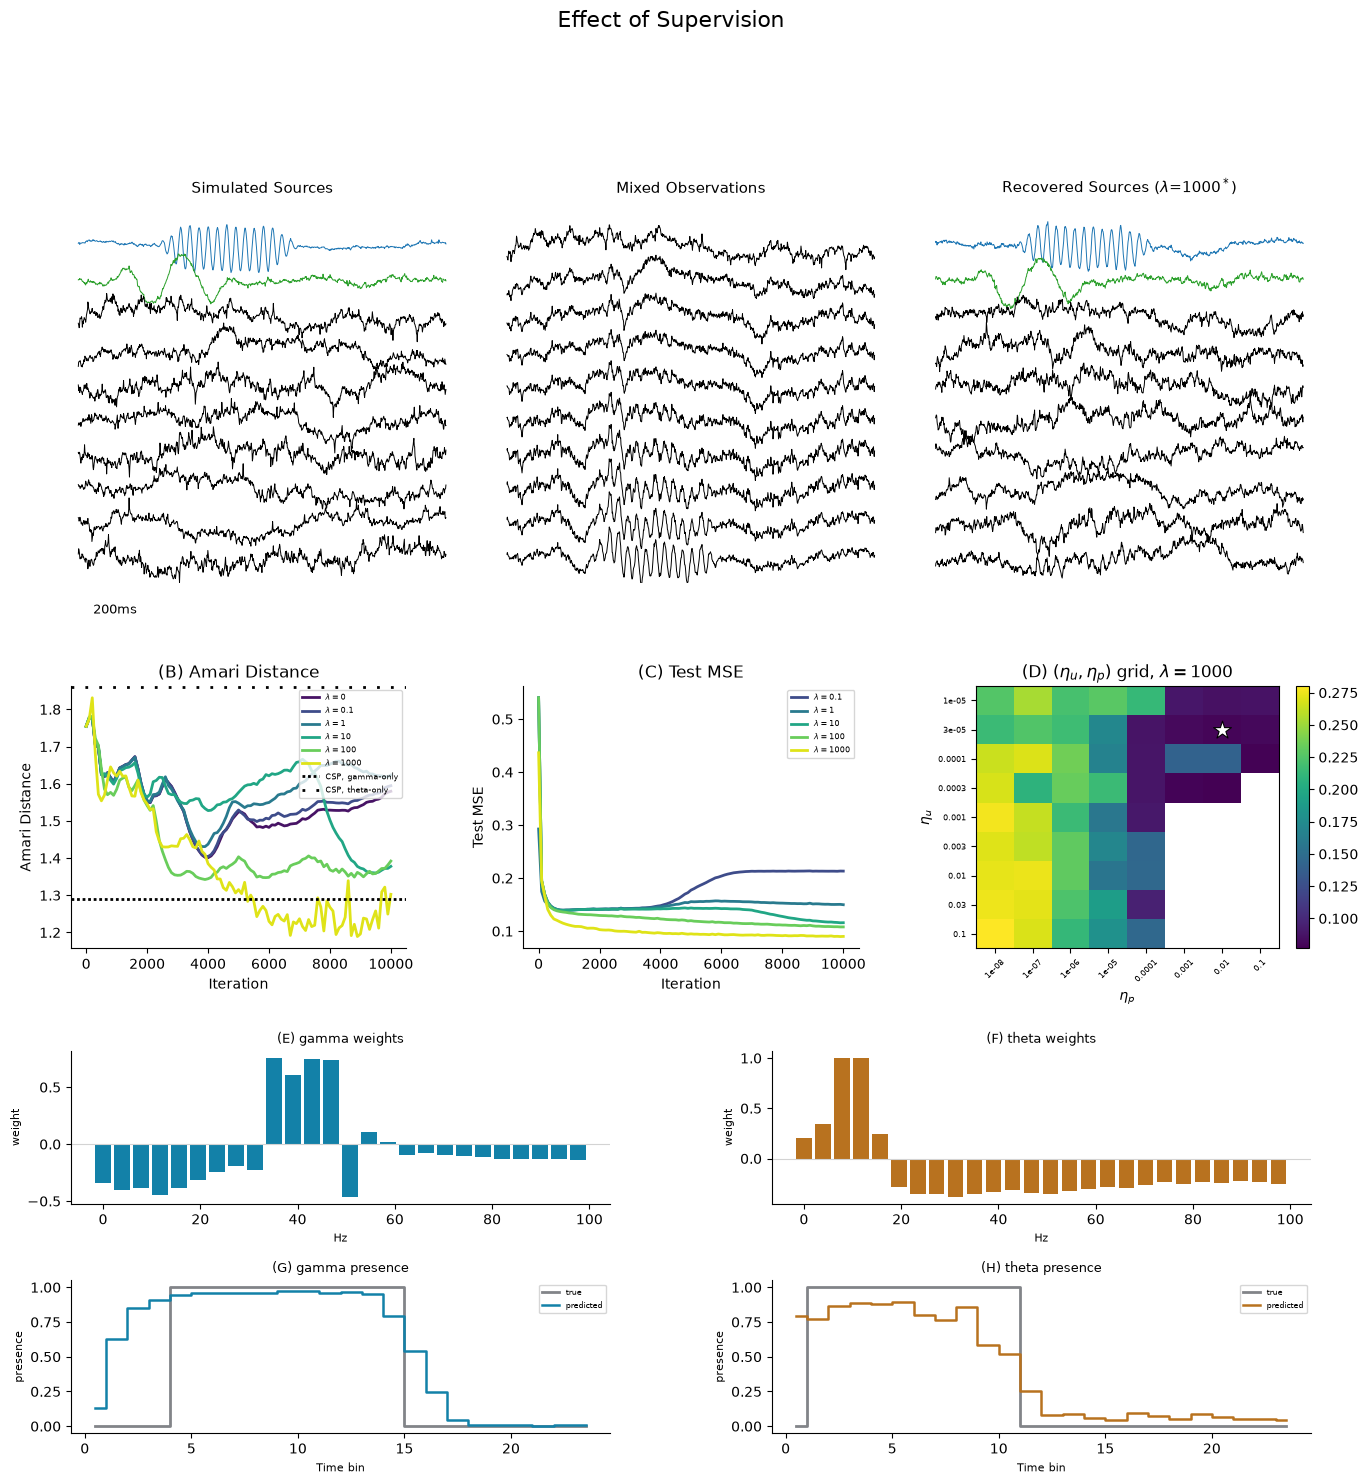

In [15]:
fig_path = fig4(grid_high, grid_low, lambda0_result, csp_single_event, csp_presence_model, warm_all_neighbors)